In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [3]:
pd.set_option('display.max_columns', 100)

In [4]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [5]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,211,Republicans
1,220,Democrats
2,236,Democrats
3,219,Democrats
4,200,Republicans
...,...,...
19995,223,Democrats
19996,222,Democrats
19997,223,Democrats
19998,222,Democrats


In [6]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,103,1,0.005,Republicans
1,140,1,0.005,Republicans
2,148,1,0.005,Republicans
3,155,1,0.005,Republicans
4,156,1,0.005,Republicans


In [7]:
np.unique(seat_sims['seats']).shape[0]

188

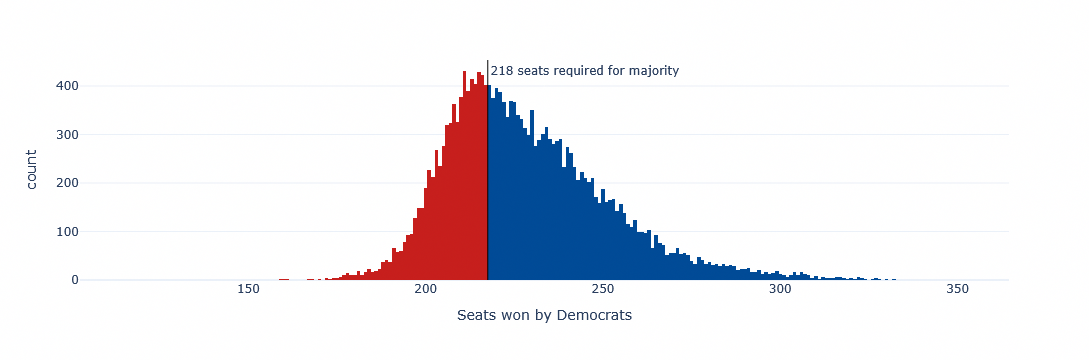

In [8]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [9]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-08-30,229.365800,US House,seats
1,2026-08-30,66.120000,US House,chance
2,2026-08-30,22.784344,US House,seats_sd
3,2026-08-30,44.972806,AK-AL,y_pred
4,2026-08-30,3.555839,AK-AL,y_pred_sd


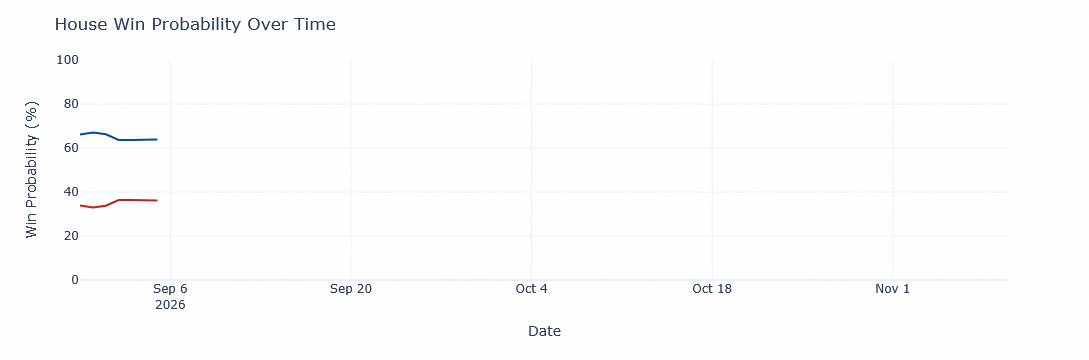

In [10]:
chance_over_time = output_ts[(output_ts['geo'] == 'US House') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-08-30'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="House Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

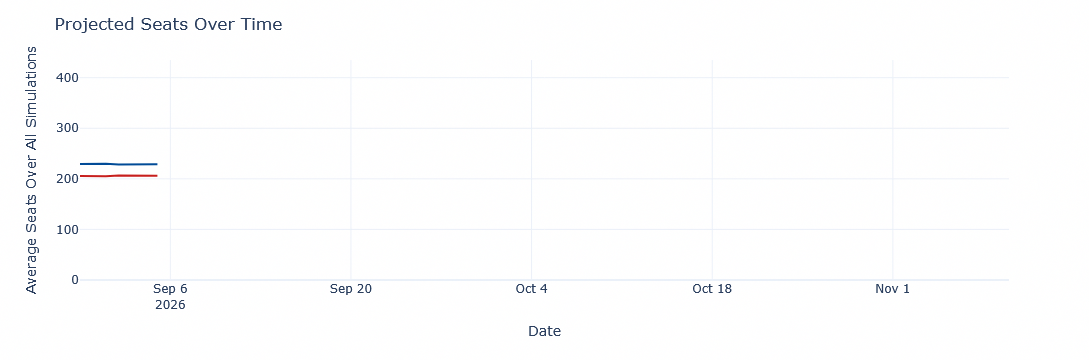

In [11]:
seats_over_time = output_ts[(output_ts['geo'] == 'US House') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 435 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-08-30'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 435]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [12]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [13]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [14]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,19950,19951,19952,19953,19954,19955,19956,19957,19958,19959,19960,19961,19962,19963,19964,19965,19966,19967,19968,19969,19970,19971,19972,19973,19974,19975,19976,19977,19978,19979,19980,19981,19982,19983,19984,19985,19986,19987,19988,19989,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
AK-AL,-4.465137,-6.485664,-2.943431,-9.539615,-12.780406,2.097103,-1.380936,-6.755584,-5.009382,-5.766854,-3.998279,-6.711594,-4.264603,-5.709998,-4.613719,-6.806856,-2.409198,-3.718827,-2.898399,-3.634450,-3.670674,-6.628712,-7.595379,-4.143161,-4.709611,-2.321526,-6.710999,-3.055813,-8.773835,-4.849971,-6.744799,-6.908177,-4.165957,-8.398541,-3.565751,-10.613296,-3.077547,-13.399590,4.375282,-14.537587,4.618084,3.982018,-2.261467,-7.735281,-4.636349,-4.567477,-0.630296,-4.280430,-7.355548,-1.915390,...,-3.911211,-10.790216,-1.838649,-14.895525,2.112439,-7.272931,-6.132067,-4.194524,-1.290171,-3.792166,-4.614895,-1.260279,-8.590238,-0.734783,-8.019603,-3.817219,-4.090590,-3.112952,-4.234028,-9.269594,-2.580995,-2.683837,-11.830795,-6.904172,-1.974582,-8.826920,-7.180413,-2.812477,-7.016677,-3.784620,-8.922080,0.284122,-5.602738,1.621349,1.127436,-8.416077,0.468273,-4.136177,-3.875957,-6.104215,-9.459117,-10.055403,-14.112669,-6.029973,-3.514526,-7.985331,-5.964250,-6.095570,-9.188104,-5.669450
AL-01,-16.474860,-12.953680,-12.877870,-15.568341,-18.773351,-9.847212,-10.473750,-17.164303,-12.977873,-13.860452,-16.764786,-15.006942,-17.162087,-9.306737,-14.352113,-11.623367,-13.344837,-8.315452,-18.143433,-14.728283,-15.375452,-14.194809,-13.839701,-14.155754,-12.558549,-13.332589,-13.669428,-13.124645,-14.803717,-13.115986,-15.982052,-17.334519,-16.787357,-21.701886,-10.095229,-16.441959,-11.996270,-25.775994,-5.001040,-18.652166,-6.277893,-3.342311,-8.968454,-17.842014,-13.171436,-17.461388,-13.124733,-12.854066,-12.687475,-10.478464,...,-13.437012,-16.105052,-11.093274,-19.857345,-7.435799,-13.669021,-11.575535,-15.417105,-14.389172,-10.670158,-14.798948,-9.225013,-17.891046,-10.484867,-18.451921,-17.495020,-11.805889,-11.644372,-16.531502,-22.070653,-7.621125,-11.544111,-20.482227,-12.458795,-12.503728,-16.536511,-15.197185,-9.294006,-16.064110,-10.414393,-16.168913,-9.198548,-18.718843,-7.609493,-8.368807,-19.143667,-8.925081,-15.837996,-13.763366,-16.158064,-18.824497,-22.146959,-24.892400,-14.593560,-14.970350,-14.667751,-14.076920,-15.515666,-10.979664,-16.823559
AL-02,-6.236484,0.153705,-1.700145,0.213169,-4.209958,-4.280228,-2.305549,-5.296128,1.491982,-3.305903,0.055230,-6.689086,-0.438514,-7.098327,-0.329706,-9.148550,4.353079,-2.967012,0.290222,-3.782201,1.892468,-7.848059,-3.596040,-2.220246,-3.552574,0.652653,-0.139319,-2.556294,2.774878,-1.095323,0.860560,-3.616722,-7.784016,-8.176149,1.230803,-7.604838,1.643149,-6.590647,-2.053251,-7.849614,1.467201,-1.265780,1.873829,-2.469683,3.117435,-3.386715,2.438549,-2.077859,-3.846487,3.995327,...,0.018716,-1.535322,-5.488055,-4.884925,2.000568,-8.670151,-3.185442,-0.767089,-6.380066,1.984116,-2.676893,-1.685884,-3.312655,-5.143078,-1.299160,-1.254919,-1.426816,-0.136984,-3.124755,-3.623817,7.257167,3.510966,-4.709648,-1.548934,-5.569359,-6.836274,-1.671102,1.068309,0.560816,0.601064,-3.349114,-0.303217,-2.310186,1.074886,2.167301,1.312799,-0.467697,-1.907803,-2.455602,1.283685,-4.563461,-8.831182,-5.040376,-2.974643,-1.939802,0.614998,-2.750832,-6.583560,0.641032,-6.784162
AL-03,-21.228948,-22.647176,-19.583819,-25.908494,-30.715313,-14.564493,-17.468447,-17.888444,-22.690990,-20.210051,-20.109822,-19.536600,-22.232024,-17.468593,-22.530611,-19.007648,-21.274249,-21.105463,-21.977515,-18.413921,-22.895468,-21.719523,-21.273788,-19.981143,-23.546255,-17.362130,-23.275036,-21.823830,-25.702896,-21.726913,-20.960388,-20.141108,-21.332642,-24.900154,-19.549595,-18.854793,-19.452961,-27.970155,-13.982255,-28.910643,-15.993800,-11.482023,-18

In [15]:
sim_corr = post_untransp.corr()

In [16]:
sim_corr

,AK-AL,AL-01,AL-02,AL-03,AL-04,AL-05,AL-06,AL-07,AR-01,AR-02,AR-03,AR-04,AZ-01,AZ-02,AZ-03,AZ-04,AZ-05,AZ-06,AZ-07,AZ-08,AZ-09,CA-01,CA-02,CA-03,CA-05,CA-06,CA-08,CA-09,CA-10,CA-13,CA-15,CA-16,CA-17,CA-18,CA-19,CA-20,CA-21,CA-22,CA-23,CA-24,CA-25,CA-26,CA-27,CA-28,CA-30,CA-31,CA-32,CA-33,CA-35,CA-36,...,TX-25,TX-26,TX-27,TX-28,TX-29,TX-30,TX-31,TX-32,TX-33,TX-34,TX-35,TX-36,TX-37,TX-38,UT-01,UT-02,UT-03,UT-04,VA-01,VA-02,VA-03,VA-04,VA-05,VA-06,VA-07,VA-08,VA-09,VA-10,VA-11,VT-AL,WA-01,WA-02,WA-03,WA-04,WA-05,WA-06,WA-07,WA-08,WA-09,WA-10,WI-01,WI-03,WI-04,WI-05,WI-06,WI-07,WI-08,WV-01,WV-02,WY-AL
AK-AL,1.000000,0.727336,0.505104,0.752858,0.739801,0.728765,0.746316,0.515044,0.747754,0.750660,0.750757,0.748286,0.515504,0.511387,0.513073,0.528785,0.714801,0.730700,0.738837,0.731630,0.752323,0.715687,0.526090,0.537588,0.751835,0.744804,0.587641,0.530293,0.534047,0.530588,0.504819,0.716219,0.588423,0.527482,0.527611,0.718921,0.530088,0.751050,0.743554,0.535701,0.529998,0.719128,0.512070,0.534408,0.507922,0.548096,0.571564,0.531015,0.584857,0.534567,...,0.747377,0.731411,0.566426,0.528111,0.528554,0.714653,0.755315,0.712755,0.554215,0.529843,0.716310,0.547420,0.515682,0.509866,0.513807,0.743596,0.730189,0.732980,0.758067,0.571574,0.530271,0.508027,0.733812,0.748381,0.509244,0.534229,0.745560,0.505193,0.714518,0.547976,0.535206,0.531804,0.514722,0.715477,0.559770,0.506753,0.523479,0.525150,0.589509,0.520825,0.746621,0.567774,0.589843,0.746176,0.755323,0.714173,0.732837,0.745461,0.731506,0.714561
AL-01,0.727336,1.000000,0.511778,0.752303,0.744711,0.739700,0.754650,0.522234,0.746016,0.749781,0.751849,0.749521,0.518099,0.515274,0.517081,0.533237,0.715862,0.732090,0.740376,0.733275,0.749518,0.714335,0.525966,0.539457,0.753971,0.738096,0.593539,0.536118,0.535100,0.533423,0.512477,0.712248,0.592955,0.530559,0.529987,0.717731,0.530926,0.753845,0.739770,0.533696,0.532528,0.712407,0.515967,0.535501,0.509133,0.559213,0.580087,0.535511,0.589554,0.535917,...,0.746091,0.729234,0.575183,0.530476,0.533038,0.708384,0.755778,0.715019,0.558177,0.536210,0.714218,0.553193,0.515387,0.521187,0.518922,0.746326,0.731752,0.732942,0.753979,0.570386,0.535093,0.512231,0.727710,0.743224,0.509678,0.535848,0.748896,0.507586,0.715921,0.548884,0.536198,0.534283,0.519319,0.718587,0.564610,0.510199,0.525976,0.526298,0.597641,0.521306,0.747306,0.570688,0.593404,0.747473,0.754749,0.719298,0.733739,0.748330,0.726264,0.717888
AL-02,0.505104,0.511778,1.000000,0.519773,0.510609,0.500205,0.521765,0.714574,0.516029,0.519955,0.523116,0.521003,0.698056,0.684890,0.688803,0.713312,0.651455,0.500075,0.509900,0.499428,0.520382,0.650873,0.718115,0.724222,0.529315,0.509088,0.604700,0.715661,0.723172,0.545605,0.689818,0.649773,0.598318,0.716662,0.714576,0.653546,0.717419,0.519850,0.510933,0.723354,0.722158,0.655095,0.694810,0.716005,0.687059,0.571120,0.587503,0.721180,0.601164,0.722353,...,0.517213,0.500613,0.582887,0.717320,0.711089,0.653953,0.521800,0.658614,0.565138,0.713380,0.658616,0.555564,0.698760,0.697790,0.691970,0.517314,0.499047,0.506439,0.521015,0.574127,0.713188,0.687102,0.502695,0.511124,0.688630,0.721340,0.516869,0.687377,0.653255,0.559227,0.720620,0.718771,0.696216,0.658234,0.576560,0.687978,0.712701,0.714470,0.607937,0.702163,0.515223,0.576296,0.605387,0.515401,0.517148,0.653656,0.501688,0.513791,0.493125,0.653690
AL-03,0.752858,0.752303,0.519773,1.000000,0.770441,0.755205,0.776527,0.532293,0.773997,0.776866,0.768868,0.775073,0.525847,0.521853,0.525033,0.540489,0.733265,0.751506,0.757222,0.751070,0.775631,0.735727,0.537747,0.545690,0.775173,0.762007,0.602628,0.543798,0.547069,0.541882,0.519148,0.733856,0.599168,0.539741,0.539915,0.737489,0.538547,0.771455,0.762431,0.542649,0.542580,0.732263,0.523762,0.540456,0.520411,0.564284,0.587305,0.544082,0.600276,0.545921,...,0.771731,0.752044,0.582921,0.537641,0.538551,0.728771,0.776054,0.733996,0.570391,0.543970,0.734212,0.564515,0.527504,0.525127,0.526596,0.766567,0.751137,0.750762,0.778061,0.578233,0.542874,0.519862,0.75038

In [17]:
post.shape

(418, 20000)

In [18]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [19]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:32<00:00, 620.62it/s]


array(['PA-07', 'SC-01', 'NY-17', ..., 'MI-10', 'ME-02', 'FL-25'],
      shape=(20000,), dtype='<U32')

In [20]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.804888,-18.764506,-1,-37.529012,44.808112,3.615607,7.560,1,37.750881,51.886445
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.105717,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.768565,-38.923019,0,-77.846039,35.885538,3.610789,0.005,2,28.839396,42.972195
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.105717,1,0,45.599529,0.287405,45.799765,0.287405,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.287405,0.536102,0.200235,-6.937698,-19.716169,1,-39.432338,47.801238,3.539050,26.420,3,40.851844,54.762002
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.000000,0.000000,-39.536466,-45.710827,-1,-91.421653,29.288040,3.537555,0.000,4,22.271386,36.288355
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.000000,0.000000,-59.828562,-47.132870,-1,-94.265741,19.565528,3.572395,0.000,5,12.577589,26.589873


In [21]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.804888,-18.764506,-1,-37.529012,44.808112,3.615607,7.560,1,37.750881,51.886445,0.15
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.105717,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.768565,-38.923019,0,-77.846039,35.885538,3.610789,0.005,2,28.839396,42.972195,0.00
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.105717,1,0,45.599529,0.287405,45.799765,0.287405,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.287405,0.536102,0.200235,-6.937698,-19.716169,1,-39.432338,47.801238,3.539050,26.420,3,40.851844,54.762002,1.26
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.000000,0.000000,-39.536466,-45.710827,-1,-91.421653,29.288040,3.537555,0.000,4,22.271386,36.288355,0.00
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.000000,0.000000,-59.828562,-47.132870,-1,-94.265741,19.565528,3.572395,0.000,5,12.577589,26.589873,0.00


In [22]:
data.sort_values('tipping_point_prob', ascending=False).head(10)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
183,183,ME-02,Matt Dunlap,Paul LePage,False,False,ME,2,"DUNLAP, MATT","LEPAGE, PAUL",1181075.25,1418549.45,2599624.70,45.432529,54.567471,Maine,ME-02,94.623805,1.542589,0.598455,0.552005,0.848532,26.920000,-5.410176,-3.867301,-4.253020,26.830060,45.382645,0.987401,-6.105717,0,0,48.971709,0.173739,48.006269,0.173739,New England,2026,0.0,0.25284,-0.25284,23,2302,2,2064.114706,0.173739,0.416820,-9.654400e-01,-2.400323,-4.567471,0,-9.134942,49.486844,3.691801,44.300,184,42.184973,56.787308,2.740
193,193,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",1135198.13,1290223.21,2425421.34,46.804162,53.195838,Michigan,MI-10,76.551128,2.316124,5.150984,0.123322,13.269372,29.340000,-2.765891,-2.592362,-2.635744,99.999226,46.657584,0.987401,-6.105717,0,0,45.000000,0.400808,45.000000,0.400808,East North Central,2026,0.0,0.00000,0.00000,26,2610,0,2190.629568,0.400808,0.633094,-1.460326e-07,0.834229,-3.195838,0,-6.391676,50.159015,3.675179,51.545,194,42.990334,57.458348,2.720
229,229,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,2799701.44,0.00,2799701.44,100.000000,0.000000,North Carolina,NC-11,88.740422,3.902084,0.797632,1.120840,3.305854,24.807640,-7.843347,-4.057125,-5.003681,49.294326,45.192821,0.987401,-6.105717,0,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.0,0.00000,0.00000,37,3711,2,10000.000000,0.000000,0.000000,0.000000e+00,-3.901644,50.000000,0,100.000000,50.396419,3.676823,54.365,230,43.175634,57.696465,2.700
37,37,CA-22,Randy Villegas,David Valadao,False,True,CA,22,"VILLEGAS, RANDY","VALADAO, DAVID",2396295.54,1423592.37,3819887.91,62.732090,37.267910,California,CA-22,22.131732,64.469110,4.924433,0.538078,6.308791,6.196120,6.443675,-0.178428,1.477097,85.545753,49.071518,0.987401,-6.105717,0,1,48.000000,0.069734,44.000000,0.069734,Pacific,2026,0.0,0.00000,0.00000,6,622,5,3935.315176,0.069734,0.264072,-4.000000e+00,9.059912,12.732090,-1,25.464181,50.465849,3.511754,55.175,38,43.512967,57.335630,2.565
84,84,FL-07,Bale Dalton,Ryan Elijah,False,False,FL,7,"DALTON, BALE","ELIJAH, RYAN",1196852.72,221855.46,1418708.18,84.362150,15.637850,Florida,FL-07,66.558362,19.398792,2.991603,0.123627,9.057449,25.552545,-5.072419,-5.558666,-5.437104,94.888595,43.691280,0.987401,-6.105717,0,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.0,0.00000,0.00000,12,1207,0,7116.972318,0.000000,0.000000,0.000000e+00,-4.768491,34.362150,0,68.724300,49.374564,3.675618,42.785,85,42.220124,56.760440,2.515
190,190,MI-07,William Lawrence,Tom Barrett,False,True,MI,7,"LAWRENCE, WILLIAM","BARRETT, THOMAS MORE",1065694.20,3350486.21,4416180.41,24.131582,75.868418,Michigan,MI-07,85.239895,4.803904,1.944855,0.170025,5.279273,36.270000,-2.003691,0.098125,-0.427329,68.756305,49.348071,0.987401,-6.105717,0,1,48.971702,0.486216,46.971702,0.486216,East North Central,2026,0.0,0.00000,0.00000,26,2607,2,582.333253,0.486216,0.697292,-2.000000e+00,5.251059,-25.868418,-1,-51.736836,50.336560,3.576226,53.875,191,43.276512,57.349012,2.480
273,273,NY-17,Cait Conley,Mike Lawler,False,True,NY,17,"CONLEY, CAIT","LAWLER, MICHAEL VINCENT",3706160.25,3186004.97,6892165.22,53.773526,46.226474,New York,NY-17,70.961924,14.978446,4.840493,0.059866,7.686273,48.490000,2.820018,1.029915,1.477441,87.206472,50.279862,0.987401,-6

In [23]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Bill Hill']
    indie_r = ['Kevin Kiley']
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [24]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.804888,-18.764506,-1,-37.529012,44.808112,3.615607,7.560,1,37.750881,51.886445,0.15,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs..."
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.105717,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.768565,-38.923019,0,-77.846039,35.885538,3.610789,0.005,2,28.839396,42.972195,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<..."
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.105717,1,0,45.599529,0.287405,45.799765,0.287405,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.287405,0.536102,0.200235,-6.937698,-19.716169,1,-39.432338,47.801238,3.539050,26.420,3,40.851844,54.762002,1.26,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)..."
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.000000,0.000000,-39.536466,-45.710827,-1,-91.421653,29.288040,3.537555,0.000,4,22.271386,36.288355,0.00,Safe R,"<b style=""color:#366bbf;"">Lee McInnis (D)</b> ..."
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.000000,0.000000,-59.828562,-47.132870,-1,-94.265741,19.565528,3.572395,0.000,5,12.577589,26.589873,0.00,Safe R,"<b style=""color:#366bbf;"">Amanda Pusczek (D)</..."


In [25]:
data['projected_winner'] = data['chance'].map(lambda x: '(D)' if x > 50 else '(R)')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.804888,-18.764506,-1,-37.529012,44.808112,3.615607,7.560,1,37.750881,51.886445,0.15,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R)
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.105717,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.768565,-38.923019,0,-77.846039,35.885538,3.610789,0.005,2,28.839396,42.972195,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R)
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.105717,1,0,45.599529,0.287405,45.799765,0.287405,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.287405,0.536102,0.200235,-6.937698,-19.716169,1,-39.432338,47.801238,3.539050,26.420,3,40.851844,54.762002,1.26,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R)


In [26]:
pvi_24 = pd.read_csv('../../transformed/pvi/past_pres_results_by24dist.csv')
data = pd.merge(left=data, right=pvi_24[['district', 'party']], left_on='cd', right_on='district')
data = data.rename({'party': 'curr_party'}, axis=1)
data['hold'] = data['projected_winner'] ==  data['curr_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.105717,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.0,0.0,0.0,-6.804888,-18.764506,-1,-37.529012,44.808112,3.615607,7.560,1,37.750881,51.886445,0.15,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.105717,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.0,0.0,0.0,-28.768565,-38.923019,0,-77.846039,35.885538,3.610789,0.005,2,28.839396,42.972195,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,


In [27]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.804888,-18.764506,-1,-37.529012,44.808112,3.615607,7.560,1,37.750881,51.886445,0.15,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+10.4
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.105717,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.768565,-38.923019,0,-77.846039,35.885538,3.610789,0.005,2,28.839396,42.972195,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+28.2
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.105717,1,0,45.599529,0.287405,45.799765,0.287405,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.287405,0.536102,0.200235,-6.937698,-19.716169,1,-39.432338,47.801238,3.539050,26.420,3,40.851844,54.762002,1.26,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+4.4


In [28]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.804888,-18.764506,-1,-37.529012,44.808112,3.615607,7.560,1,37.750881,51.886445,0.15,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+10.4,92.440,7.6,92.4,7.6%,92.4%
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.105717,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.768565,-38.923019,0,-77.846039,35.885538,3.610789,0.005,2,28.839396,42.972195,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+28.2,99.995,0.0,100.0,<1%,>99%
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.105717,1,0,45.599529,0.287405,45.799765,0.287405,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.287405,0.536102,0.200235,-6.937698,-19.716169,1,-39.432338,47.801238,3.539050,26.420,3,40.851844,54.762002,1.26,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+4.4,73.580,26.4,73.6,26.4%,73.6%


In [29]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.105717,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.804888,-18.764506,-1,-37.529012,44.808112,3.615607,7.560,1,37.750881,51.886445,0.15,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+10.4,92.440,7.6,92.4,7.6%,92.4%,3.309349
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.105717,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.768565,-38.923019,0,-77.846039,35.885538,3.610789,0.005,2,28.839396,42.972195,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+28.2,99.995,0.0,100.0,<1%,>99%,8.115548
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.105717,1,0,45.599529,0.287405,45.799765,0.287405,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.287405,0.536102,0.200235,-6.937698,-19.716169,1,-39.432338,47.801238,3.539050,26.420,3,40.851844,54.762002,1.26,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+4.4,73.580,26.4,73.6,26.4%,73.6%,10.066905


In [30]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.105717,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.0,0.0,0.0,-6.804888,-18.764506,-1,-37.529012,44.808112,3.615607,7.560,1,37.750881,51.886445,0.15,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+10.4,92.440,7.6,92.4,7.6%,92.4%,3.309349,D+3.3
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.105717,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.0,0.0,0.0,-28.768565,-38.923019,0,-77.846039,35.885538,3.610789,0.005,2,28.839396,42.972195,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+28.2,99.995,0.0,100.0,<1%,>99%,8.115548,D+8.1


In [31]:
data['geoid']

0       200
1       101
2       102
3       103
4       104
       ... 
413    5507
414    5508
415    5401
416    5402
417    5600
Name: geoid, Length: 418, dtype: int64

In [32]:
dem_uclen = dem_uncont.shape[0]
dem_uncont['rating'] = np.full(dem_uclen, 'Safe D')
dem_uncont['chance'] = np.full(dem_uclen, 100)
dem_uncont['y_pred'] = np.full(dem_uclen, 100)
dem_uncont['swing_24_to_26'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_24_to_26_swing'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_dem_chance'] = np.full(dem_uclen, '100%')
dem_uncont['disp_rep_chance'] = np.full(dem_uclen, '0%')
dem_uncont['projected_2p_margin'] = np.full(dem_uclen, 'D+100')
dem_uncont['flip_indic'] = np.full(dem_uclen, '')
dem_uncont = dem_uncont.drop(['Unnamed: 0'], axis=1)
dem_uncont['matchup'] = dem_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                      x['dem_inc_any'], x['rep_inc_any']), axis=1)
dem_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-04,Mike Thompson/Eric Jones,Not Contested,True,False,CA,4,6,604,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Mike Thompson/Eric J..."
1,CA-07,Doris Matsui/Mai Vang,Not Contested,True,False,CA,7,6,607,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Doris Matsui/Mai Van..."
2,CA-11,Scott Weiner/Connie Chan,Not Contested,False,False,CA,11,6,611,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Scott Weiner/Connie ..."
3,CA-12,Lateefah Simon,Not Contested,True,False,CA,12,6,612,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Lateefah Simon* (D)<..."
4,CA-14,Aisha Wahab/Melissa Hernandez,Not Contested,True,False,CA,14,6,614,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Aisha Wahab/Melissa ..."


In [33]:
rep_uclen = rep_uncont.shape[0]
rep_uncont['rating'] = np.full(rep_uclen, 'Safe R')
rep_uncont['chance'] = np.full(rep_uclen, 0)
rep_uncont['y_pred'] = np.full(rep_uclen, 0)
rep_uncont['swing_24_to_26'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_24_to_26_swing'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_dem_chance'] = np.full(rep_uclen, '0%')
rep_uncont['disp_rep_chance'] = np.full(rep_uclen, '100%')
rep_uncont['projected_2p_margin'] = np.full(rep_uclen, 'R+100')
rep_uncont['flip_indic'] = np.full(rep_uclen, '')
rep_uncont = rep_uncont.drop(['Unnamed: 0'], axis=1)
rep_uncont['matchup'] = rep_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                       x['dem_inc_any'], x['rep_inc_any']), axis=1)
rep_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-40,Not Contested,Young Kim/Ken Calvert,False,True,CA,40,6,640,Safe R,0,0,NaN,NaN,0%,100%,R+100,,"<b style=""color:#366bbf;"">Not Contested (D)</b..."


In [34]:
incl_cols = ['cd', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'geoid', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = pd.concat([data[incl_cols], dem_uncont[incl_cols], rep_uncont[incl_cols]], axis=0)
disp_data.shape

(435, 16)

In [35]:
tab_data = data[['cd', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Bill Hill', 'Kevin Kiley'] else x)
tab_data = tab_data.rename({
    'cd': 'District',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,District,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,AK-AL,Bill Hill (Ind),Nick Begich,Very Likely R,"<p style=""color:blue;"">7.6%</p>","<p style=""color:red;"">92.4%</p>",R+10.4,D+3.3,0.15
1,AL-01,Clyde Jones Jr.,Jerry Carl,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+28.2,D+8.1,0.00
2,AL-02,Shomari Figures,Rhett Marques,Lean R,"<p style=""color:blue;"">26.4%</p>","<p style=""color:red;"">73.6%</p>",R+4.4,D+10.1,1.26
3,AL-03,Lee McInnis,Mike Rogers,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+41.4,D+5.6,0.00
4,AL-04,Amanda Pusczek,Robert Aderholt,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+60.9,D+6.1,0.00


In [36]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

7.132028960300007

In [37]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,vars,x
0,means_seats_tot,228.704100
1,chamber_win_chance,63.910000
0,sv_bias,7.132029


In [38]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [39]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 435 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Win Probability,Seat Share
0,Democrats,63.91,228.7041
1,Republicans,36.09,206.2959


In [40]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')